# Step 7 - ACF and PACF Diagnostics

This notebook studies the autocorrelation structure of the selected transformed series. The objective is to turn the stationarity and seasonality work into a short list of plausible SARIMA orders.


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

PROCESSED_PATH = "../data/processed/"
FIGURES_PATH = "../reports/figures/"
SAMPLE_HOURS = 24 * 180

os.makedirs(FIGURES_PATH, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

transformed_series = pd.read_csv(
    os.path.join(PROCESSED_PATH, "pjme_transformed.csv"),
    parse_dates=["Datetime"],
    index_col="Datetime",
)["PJME_MW_transformed"].astype(float)

diagnostic_sample = transformed_series.dropna().iloc[-SAMPLE_HOURS:]

print(f"Diagnostic sample points: {len(diagnostic_sample):,}")
print(f"Diagnostic window: {diagnostic_sample.index.min()} to {diagnostic_sample.index.max()}")
diagnostic_sample.head()


Diagnostic sample points: 4,320
Diagnostic window: 2018-02-04 01:00:00 to 2018-08-03 00:00:00


Datetime
2018-02-04 01:00:00   -0.005632
2018-02-04 02:00:00   -0.011320
2018-02-04 03:00:00   -0.010629
2018-02-04 04:00:00   -0.011563
2018-02-04 05:00:00   -0.010167
Name: PJME_MW_transformed, dtype: float64

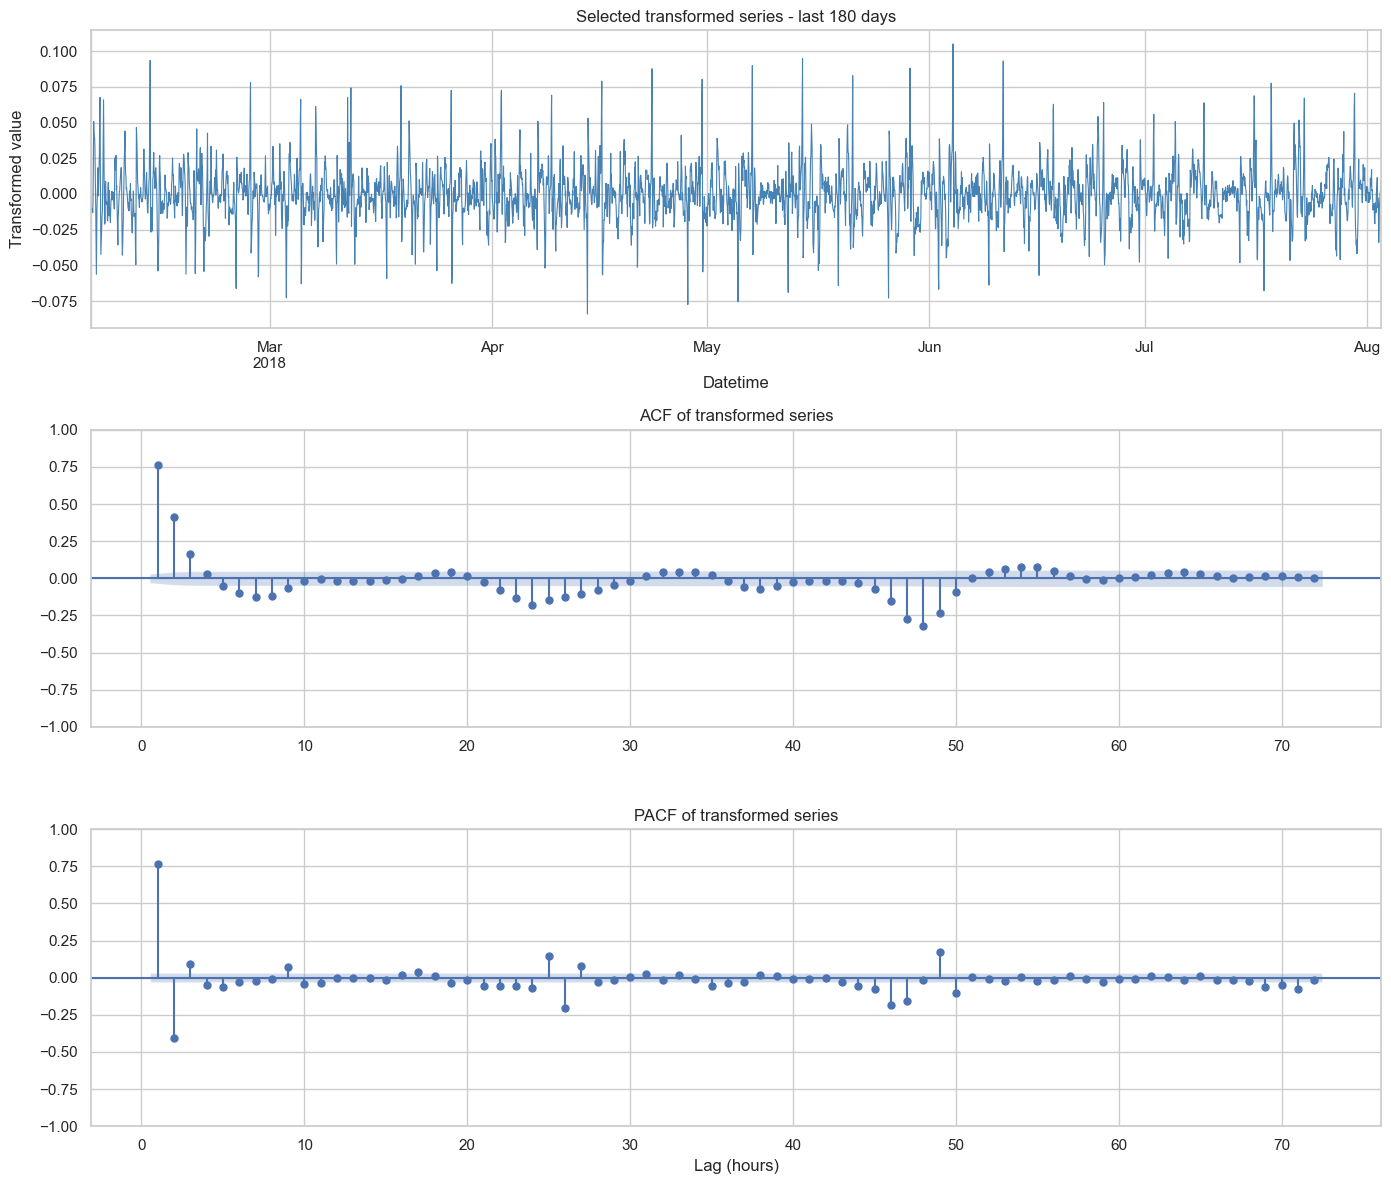

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

diagnostic_sample.plot(ax=axes[0], color="steelblue", linewidth=0.8)
axes[0].set_title("Selected transformed series - last 180 days")
axes[0].set_ylabel("Transformed value")

plot_acf(diagnostic_sample, lags=72, zero=False, ax=axes[1])
axes[1].set_title("ACF of transformed series")

plot_pacf(diagnostic_sample, lags=72, zero=False, method="ywm", ax=axes[2])
axes[2].set_title("PACF of transformed series")
axes[2].set_xlabel("Lag (hours)")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "07_acf_pacf.png"), dpi=150, bbox_inches="tight")
plt.show()


The combined plots matter more than any single spike. After the transformation we expect short-memory behavior near the first few lags, plus a remaining seasonal signature around lag 24 that can help guide the SARIMA seasonal orders.


In [3]:
max_lag = 72
acf_values = acf(diagnostic_sample, nlags=max_lag, fft=True)
pacf_values = pacf(diagnostic_sample, nlags=max_lag, method="ywm")
significance_band = 1.96 / np.sqrt(len(diagnostic_sample))

acf_pacf_summary = pd.DataFrame(
    {
        "lag": np.arange(1, max_lag + 1),
        "acf": acf_values[1:],
        "pacf": pacf_values[1:],
    }
)
acf_pacf_summary["significant_acf"] = acf_pacf_summary["acf"].abs() > significance_band
acf_pacf_summary["significant_pacf"] = acf_pacf_summary["pacf"].abs() > significance_band
acf_pacf_summary["suggested_signal"] = np.select(
    [
        acf_pacf_summary["significant_acf"] & acf_pacf_summary["significant_pacf"],
        acf_pacf_summary["significant_pacf"],
        acf_pacf_summary["significant_acf"],
    ],
    [
        "shared_acf_pacf_signal",
        "possible_ar_signal",
        "possible_ma_signal",
    ],
    default="weak_signal",
)

display(acf_pacf_summary.head(30).style.format({"acf": "{:,.4f}", "pacf": "{:,.4f}"}))
print(f"Approximate significance band: +/- {significance_band:.4f}")

acf_pacf_summary.to_csv(os.path.join(PROCESSED_PATH, "acf_pacf_summary.csv"), index=False)


,lag,acf,pacf,significant_acf,significant_pacf,suggested_signal
0,1,0.7636,0.7636,True,True,shared_acf_pacf_signal
1,2,0.4134,-0.4070,True,True,shared_acf_pacf_signal
2,3,0.1667,0.0956,True,True,shared_acf_pacf_signal
3,4,0.0315,-0.0473,True,True,shared_acf_pacf_signal
4,5,-0.0493,-0.0602,True,True,shared_acf_pacf_signal
5,6,-0.1002,-0.0301,True,True,shared_acf_pacf_signal
6,7,-0.1231,-0.0231,True,False,possible_ma_signal
7,8,-0.1180,-0.0060,True,False,possible_ma_signal
8,9,-0.0672,0.0749,True,True,shared_acf_pacf_signal
9,10,-0.0176,-0.0422,False,True,possible_ar_signal


Approximate significance band: +/- 0.0298


In this project the most useful interpretation is usually a compact one: strong activity in the first one or two lags points toward low-order non-seasonal AR or MA terms, while the remaining seasonal structure near lag 24 supports at least one seasonal parameter in the SARIMA search.


In [4]:
candidate_order_guidance = pd.DataFrame(
    [
        {
            "component": "non_seasonal_ar_order_p",
            "recommended_values": "1 or 2",
            "reason": "PACF typically shows its clearest spikes at the first two lags.",
        },
        {
            "component": "non_seasonal_ma_order_q",
            "recommended_values": "0 or 1",
            "reason": "ACF usually drops quickly after the first few lags once differenced.",
        },
        {
            "component": "seasonal_ar_order_P",
            "recommended_values": "0 or 1",
            "reason": "Seasonal structure remains visible but not dominant after differencing.",
        },
        {
            "component": "seasonal_ma_order_Q",
            "recommended_values": "0 or 1",
            "reason": "Seasonal spikes around lag 24 often align with a parsimonious seasonal MA term.",
        },
        {
            "component": "seasonal_period_s",
            "recommended_values": "24",
            "reason": "The strongest repeating cycle in the raw series is daily.",
        },
    ]
)

display(candidate_order_guidance)
candidate_order_guidance.to_csv(
    os.path.join(PROCESSED_PATH, "acf_pacf_guidance.csv"), index=False
)


,component,recommended_values,reason
0,non_seasonal_ar_order_p,1 or 2,PACF typically shows its clearest spikes at th...
1,non_seasonal_ma_order_q,0 or 1,ACF usually drops quickly after the first few ...
2,seasonal_ar_order_P,0 or 1,Seasonal structure remains visible but not dom...
3,seasonal_ma_order_Q,0 or 1,Seasonal spikes around lag 24 often align with...
4,seasonal_period_s,24,The strongest repeating cycle in the raw serie...


Final takeaway: keep the SARIMA search narrow and interpretable. The diagnostics support testing low-order models centered on `d=1`, `D=1`, `s=24`, with `p` near 1 to 2 and seasonal terms no larger than 1.
